IMAGE CLASSIFICATION

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt  # Import matplotlib for plotting
import seaborn as sns
from PIL import Image, ImageEnhance, ImageFilter
from sklearn.cluster import KMeans
from tqdm import tqdm
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Show some sample images

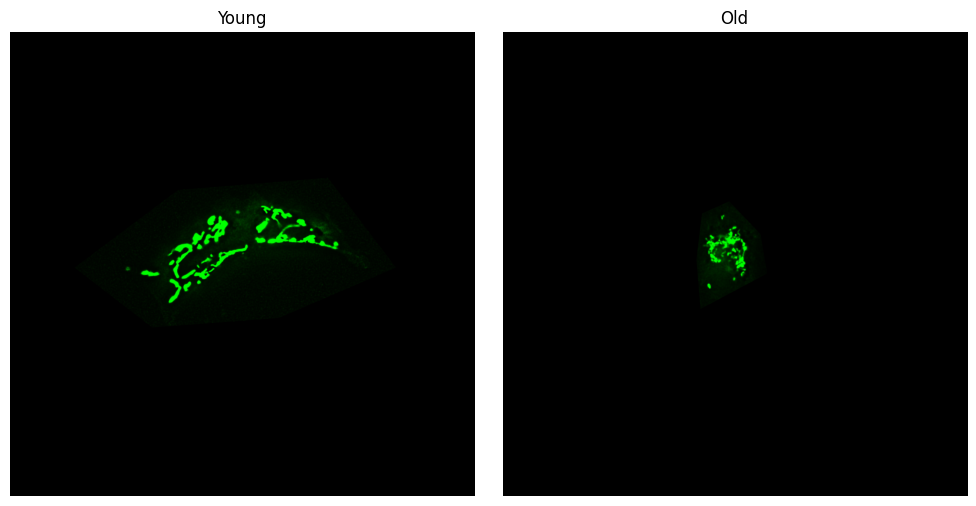

In [4]:
img_paths = [
    '/content/drive/MyDrive/Images/nuclei/training_set9/newest/aged/1002-2.tif',
    '/content/drive/MyDrive/Images/nuclei/training_set9/newest/young/1-1.tif'
    ]

plt.figure(figsize=(10, 5))

titles = ['Young', 'Old']

for i, path in enumerate(img_paths):
    img = plt.imread(path)
    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(titles[i])

plt.tight_layout()
plt.show()

In [ ]:
def load_data_array(images, size=512):
  # Resize images
  for index, filename in enumerate(images):
    print(f'Index  {index}    Filename: {filename}')
  if (size!="NONE"):
    data_array = np.array([np.array(Image.open(filename).resize((size, size))) for filename in images])
  else:
    data_array = np.array([np.array(Image.open(filename)) for filename in images])

  data_array = data_array / 255.0  # Normalize pixel values

  # Enhance brightness
  enhanced_images = []
  for img in data_array:
    enhancer = ImageEnhance.Brightness(Image.fromarray((img * 255).astype(np.uint8)))
    enhanced_img = enhancer.enhance(1.1)  # Adjust brightness factor (e.g., 1.2)
    enhanced_images.append(np.array(enhanced_img) / 255.0)

  # Apply sharpening
  sharpened_images = []
  for img in enhanced_images:
    sharpened_img = Image.fromarray((img * 255).astype(np.uint8)).filter(ImageFilter.SHARPEN)
    sharpened_images.append(np.array(sharpened_img) / 255.0)
  return np.array(sharpened_images).reshape(len(images), -1)  # Flatten images

In [ ]:
def run_clustering(data, num_clusters=2):
  kmeans = KMeans(n_clusters=num_clusters, random_state=None)
  kmeans.fit(data)
  return kmeans.predict(data)

In [ ]:
# NOT USED YET:
# Generate a feature stack (pixel values, blurred, and edges)
from skimage.io import imread
from skimage import filters
from sklearn.ensemble import RandomForestClassifier
def generate_feature_stack(image):
    blurred = filters.gaussian(image, sigma=2)
    edges = filters.sobel(blurred)
    feature_stack = [image.ravel(), blurred.ravel(), edges.ravel()]
    return np.asarray(feature_stack)

In [ ]:
def main(image_path='c:/content/images', num_clusters=2, num_runs=4, size=512):
  image_path = image_path  # Update with your actual image path
  image_list = glob.glob(f'{image_path}/*.tif*')
  data = load_data_array(image_list, size)

  # Create 1D array with all zeros
  small_cluster_count = np.zeros((len(image_list),))

  for i in tqdm(range(num_runs)):
    cluster_labels = run_clustering(data=data, num_clusters=num_clusters)
    print(f"\nRun {i+1}\n{cluster_labels}")

    # Count the occurrences of each cluster label
    label_counts = np.bincount(cluster_labels)

    # Determine the smaller group (assuming it's the one with fewer images)
    smaller_group_label = np.argmin(label_counts)

    print(f"Cluster {smaller_group_label} corresponds to the smaller group:")
    # Print the smaller group images
    for index, label in enumerate(cluster_labels):
      if label == smaller_group_label:
        print(f"Image {index}: Cluster {label}  FN {image_list[index]}")
        # update small_cluster_count at that position
        small_cluster_count[index] +=1

  # Create a bar graph
  plt.figure(figsize=(10, 6))
  plt.bar(range(len(small_cluster_count)), small_cluster_count)
  plt.xlabel("Image Index")
  plt.ylabel("Occurrences in Smaller Group")
  plt.title(f"Occurrences of Images in Smaller Group - {num_runs} Runs (size {size})")
  plt.show()
  return

In [ ]:
if __name__ == '__main__':
  # Set the desired number of clusters (e.g., 2) and runs
  image_path = '/content/drive/MyDrive/AI_ML/images3'
  size='NONE'  # or "NONE" for no resize
  num_clusters = 2
  num_runs = 500

  main(image_path=image_path,
       num_clusters=num_clusters,
       num_runs=num_runs,
       size=size)